In [ ]:
import os

os.chdir(os.getenv("HOME_DIR"))

import yaml
from dotenv import load_dotenv
from tqdm import tqdm
from ultralytics import YOLO

load_dotenv()

In [ ]:
PROCESSED_DIR = os.path.join(os.getenv("HOME_DIR"), "data", "processed")
IMG_SIZE = int(os.getenv("HEIGHT")), int(os.getenv("WIDTH"))
DATASET_YAML = "bdd100k.yaml"
DATA_DIR = os.path.join(os.getenv("HOME_DIR"), "config", "datasets")
IMG_SIZE = int(os.getenv("HEIGHT")), int(os.getenv("WIDTH"))

# **Training**

In [ ]:
handle_model_yaml = "yolo8_baseline.yaml"
yaml_path = os.path.join(
    os.getenv("HOME_DIR"),
    "config",
    "models",
    handle_model_yaml,
)
with open(yaml_path, "r") as file:
    args = yaml.safe_load(file)


# Set directories path for training
PROJECT_DIR = os.path.join(
    os.getenv("HOME_DIR"), "results", "models", args["project_results_name"]
)


# Load model
resume = False
model_path = os.path.join(
    PROJECT_DIR,
    "optimized",
    "best_optimized.pt",
)
if not os.path.exists(model_path):
    model_path = os.path.join(
        PROJECT_DIR,
        args["project_results_name"],
        "train",
        "weights",
        "best.pt",
    )
    resume = True
model = YOLO(model_path, task="detect", verbose=True)


# Train
try:
    results = model.train(
        data=os.path.join(DATA_DIR, DATASET_YAML),
        project=os.path.join(PROJECT_DIR, "optimized"),
        epochs=50,
        imgsz=IMG_SIZE[0],
        batch=8,
        exist_ok=True,
        resume=resume,
        device=-1,
        patience=10,
        optimizer="AdamW",
        plots=True,
        amp=False,
    )
except Exception as e:
    print(f"Last training was finished: {e}.")

# **Results**

## **Metrics**

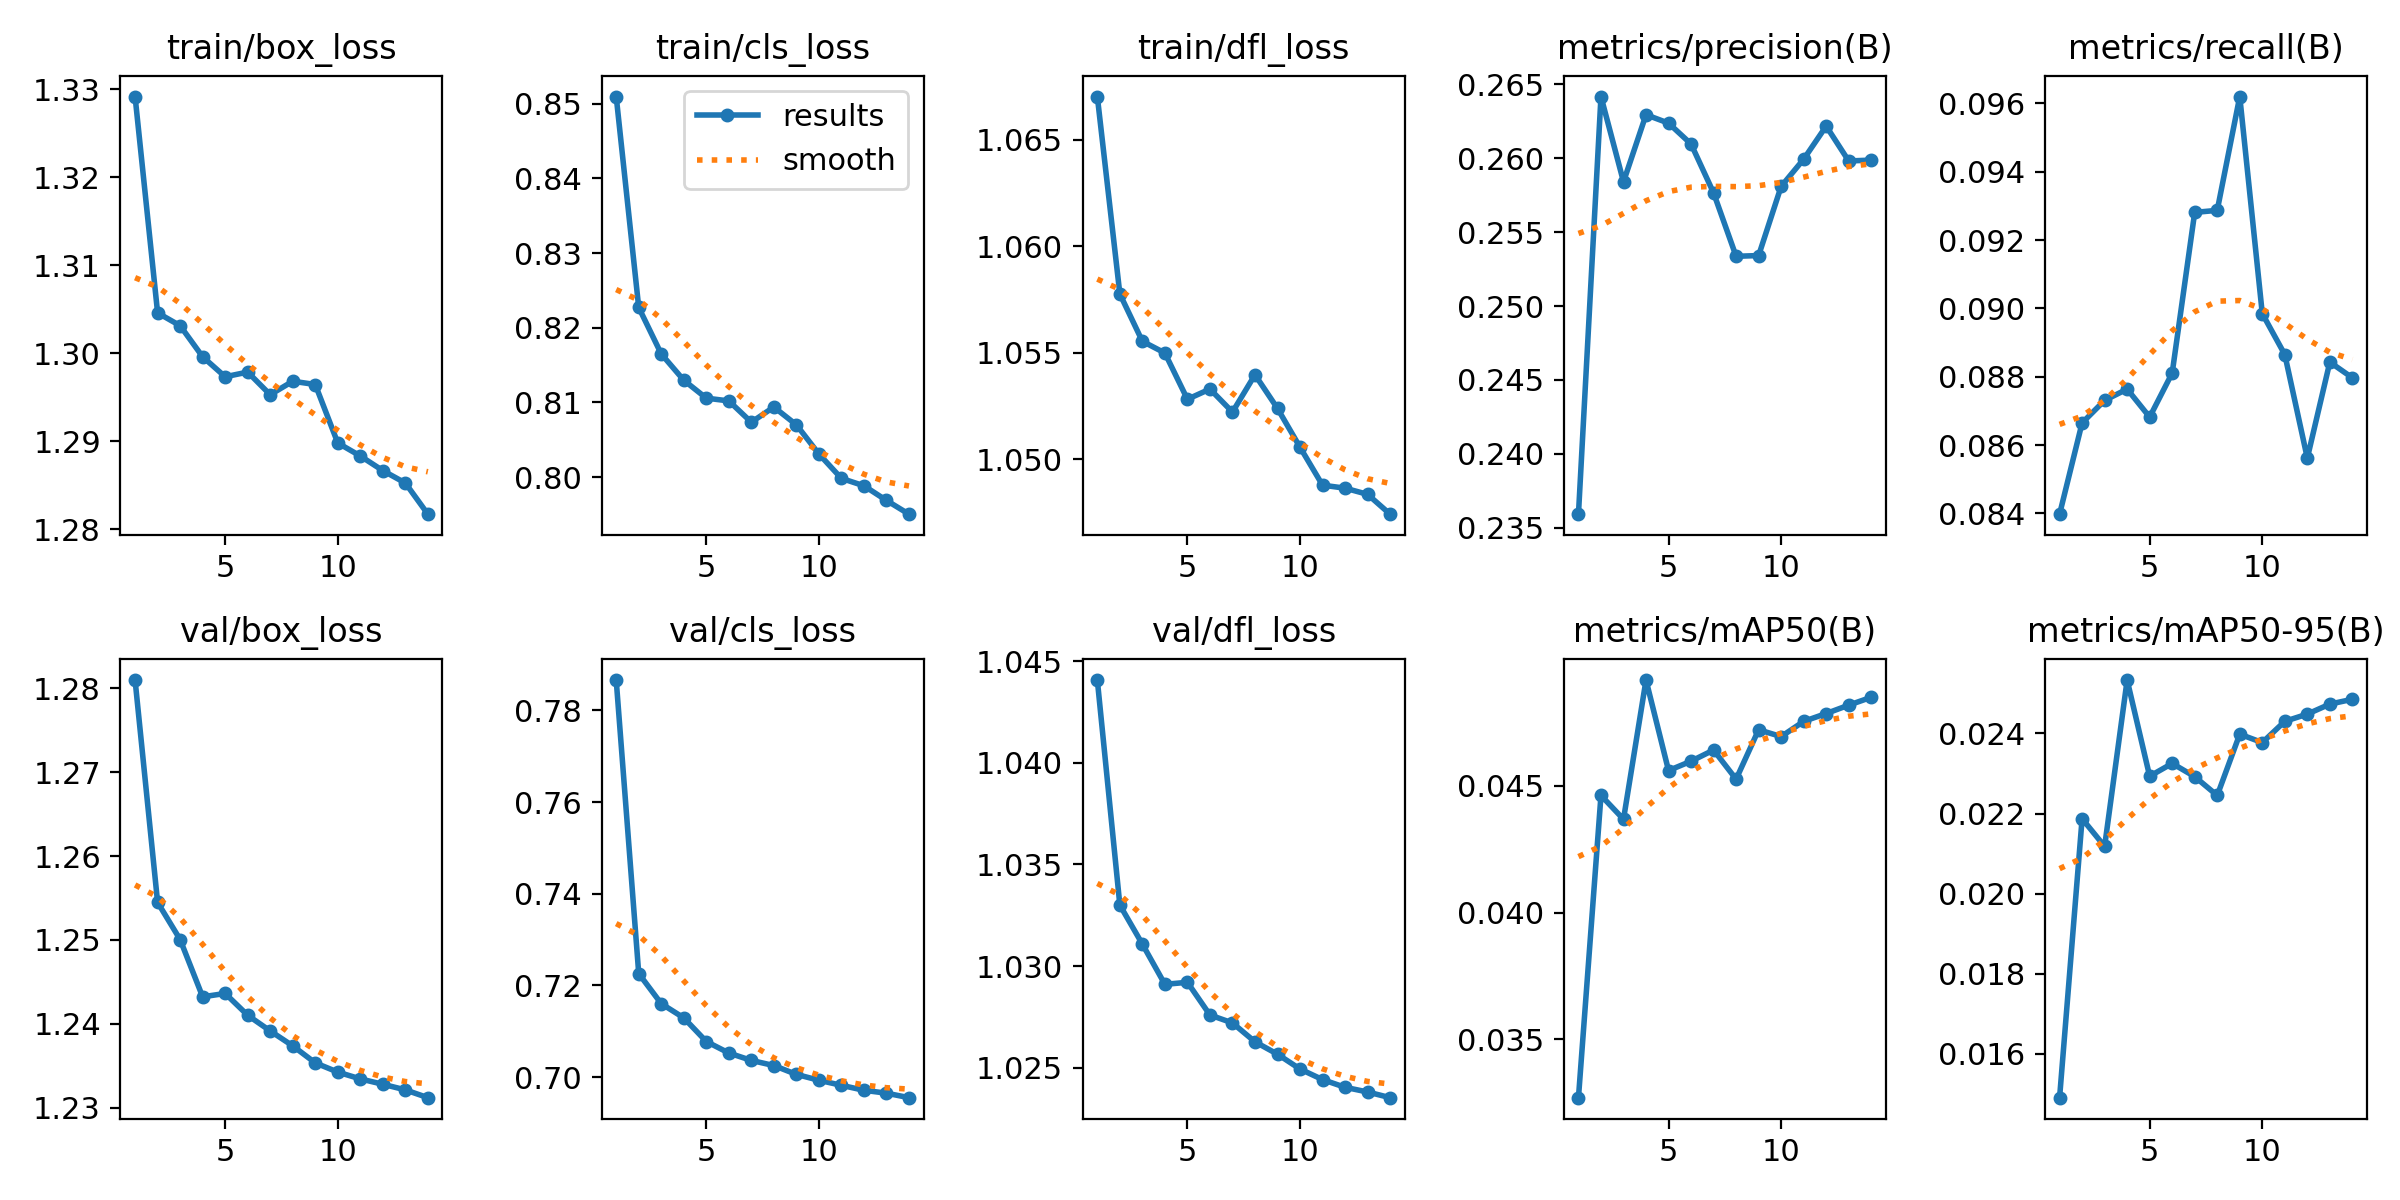
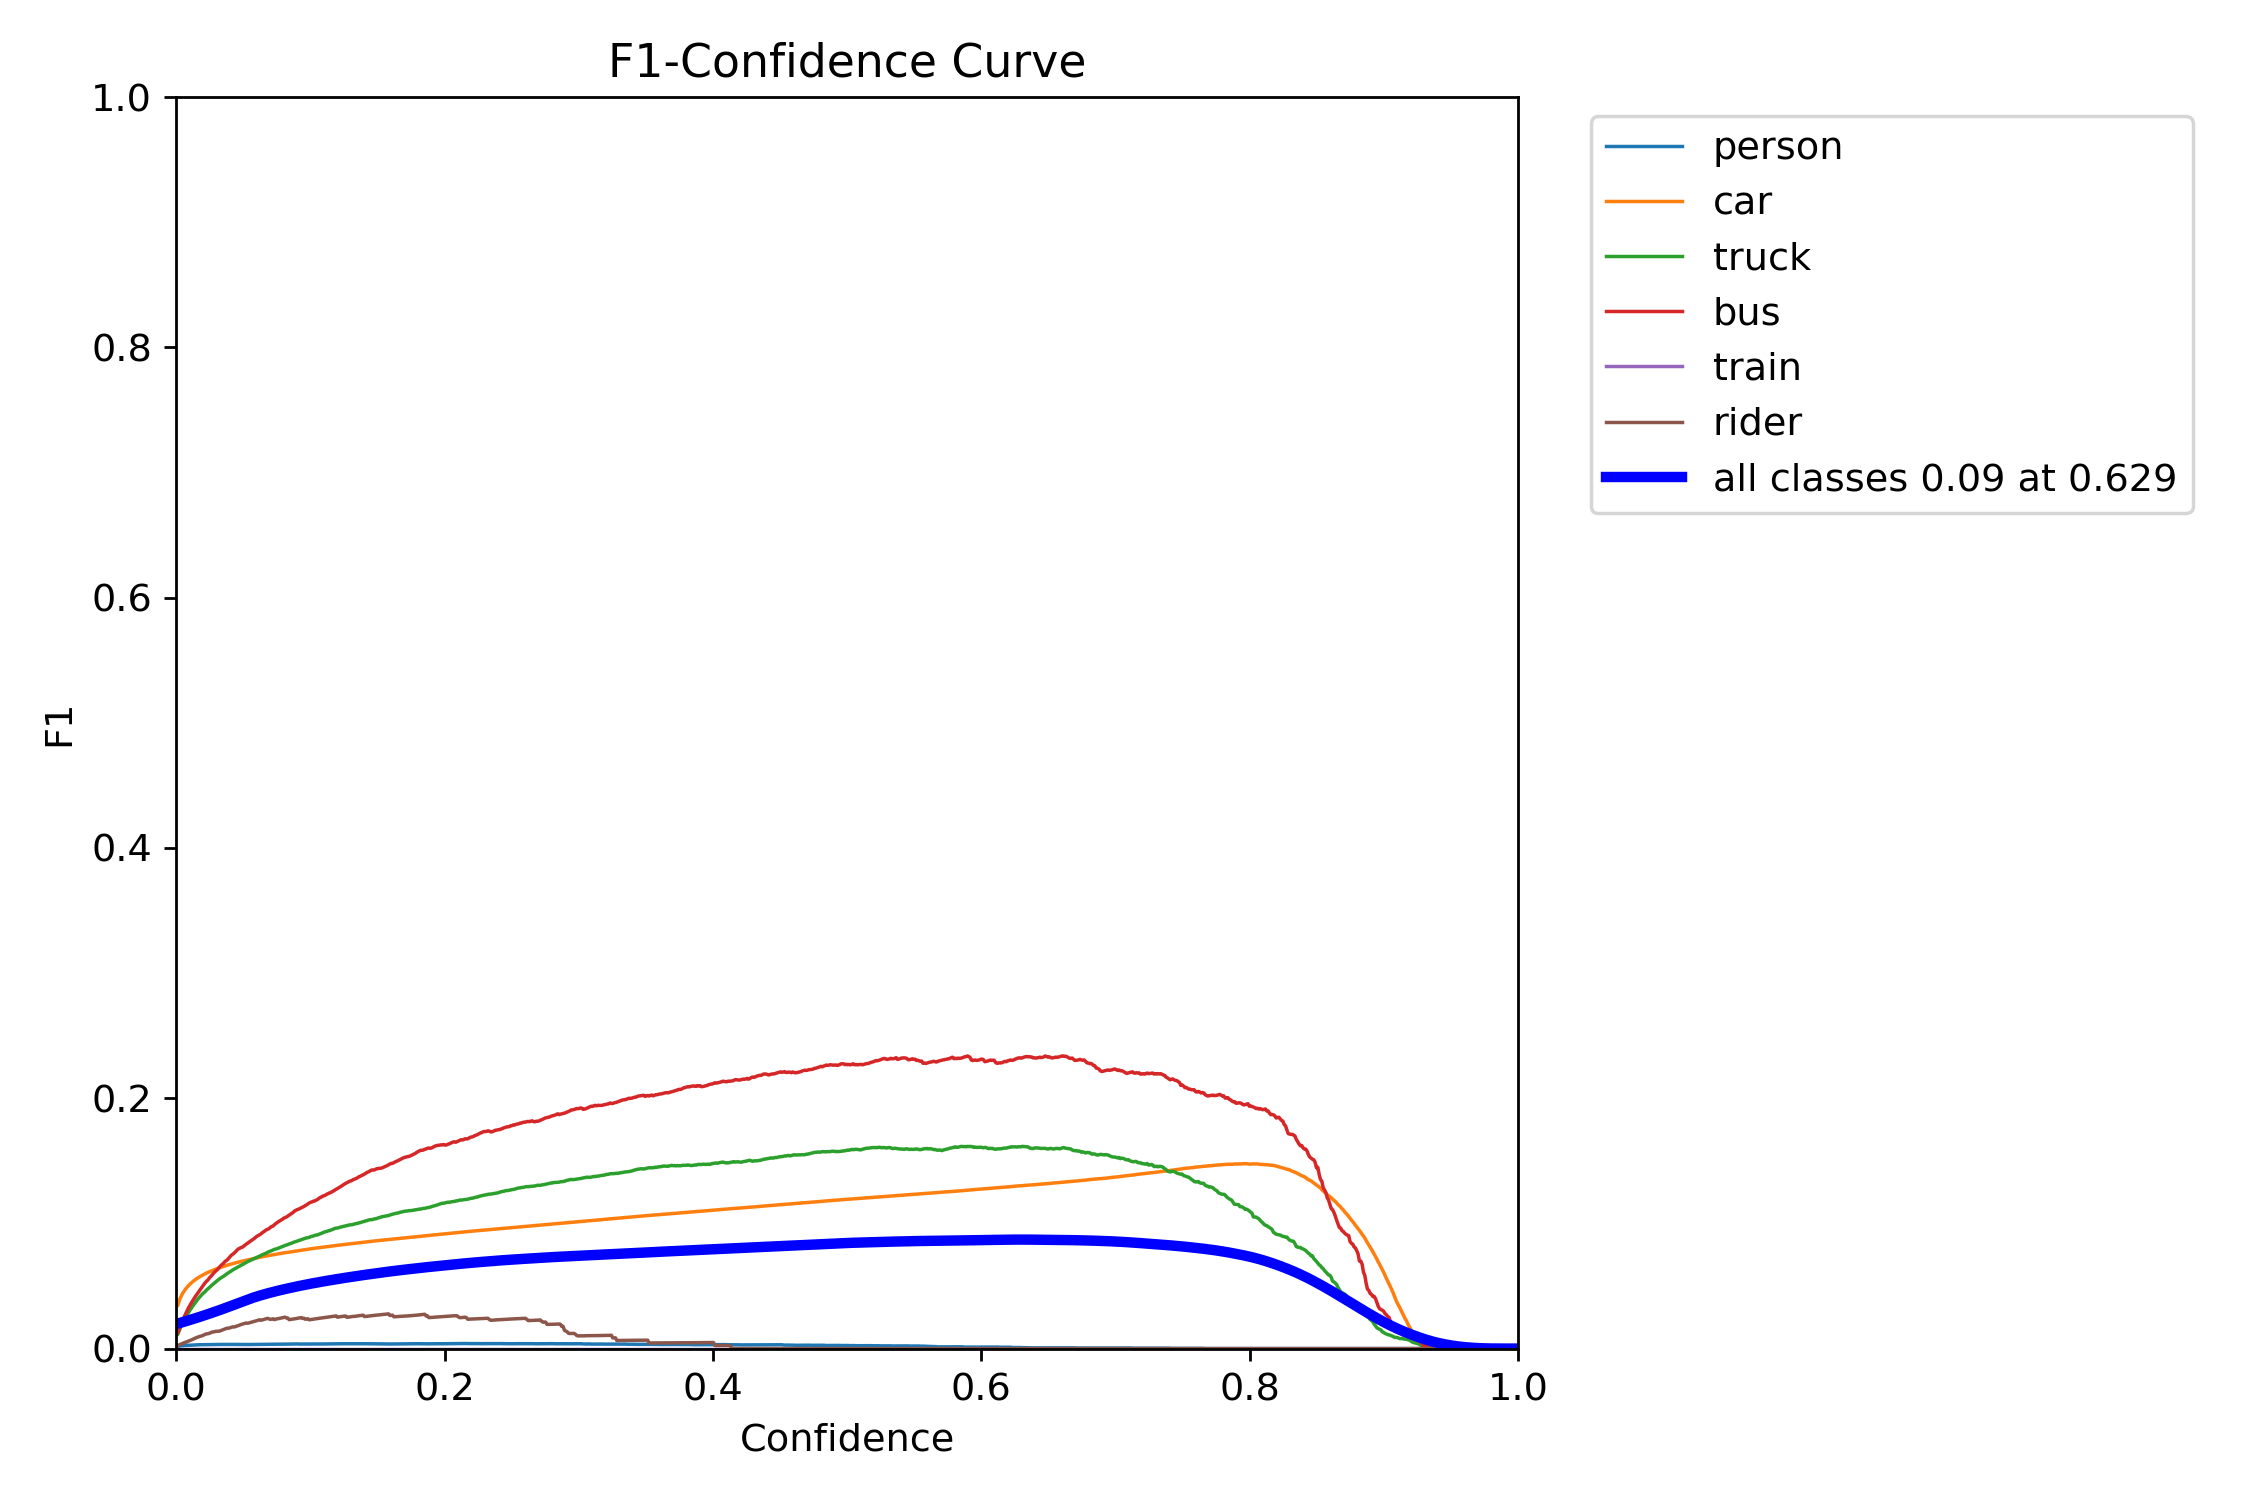

## **Predicted Images**

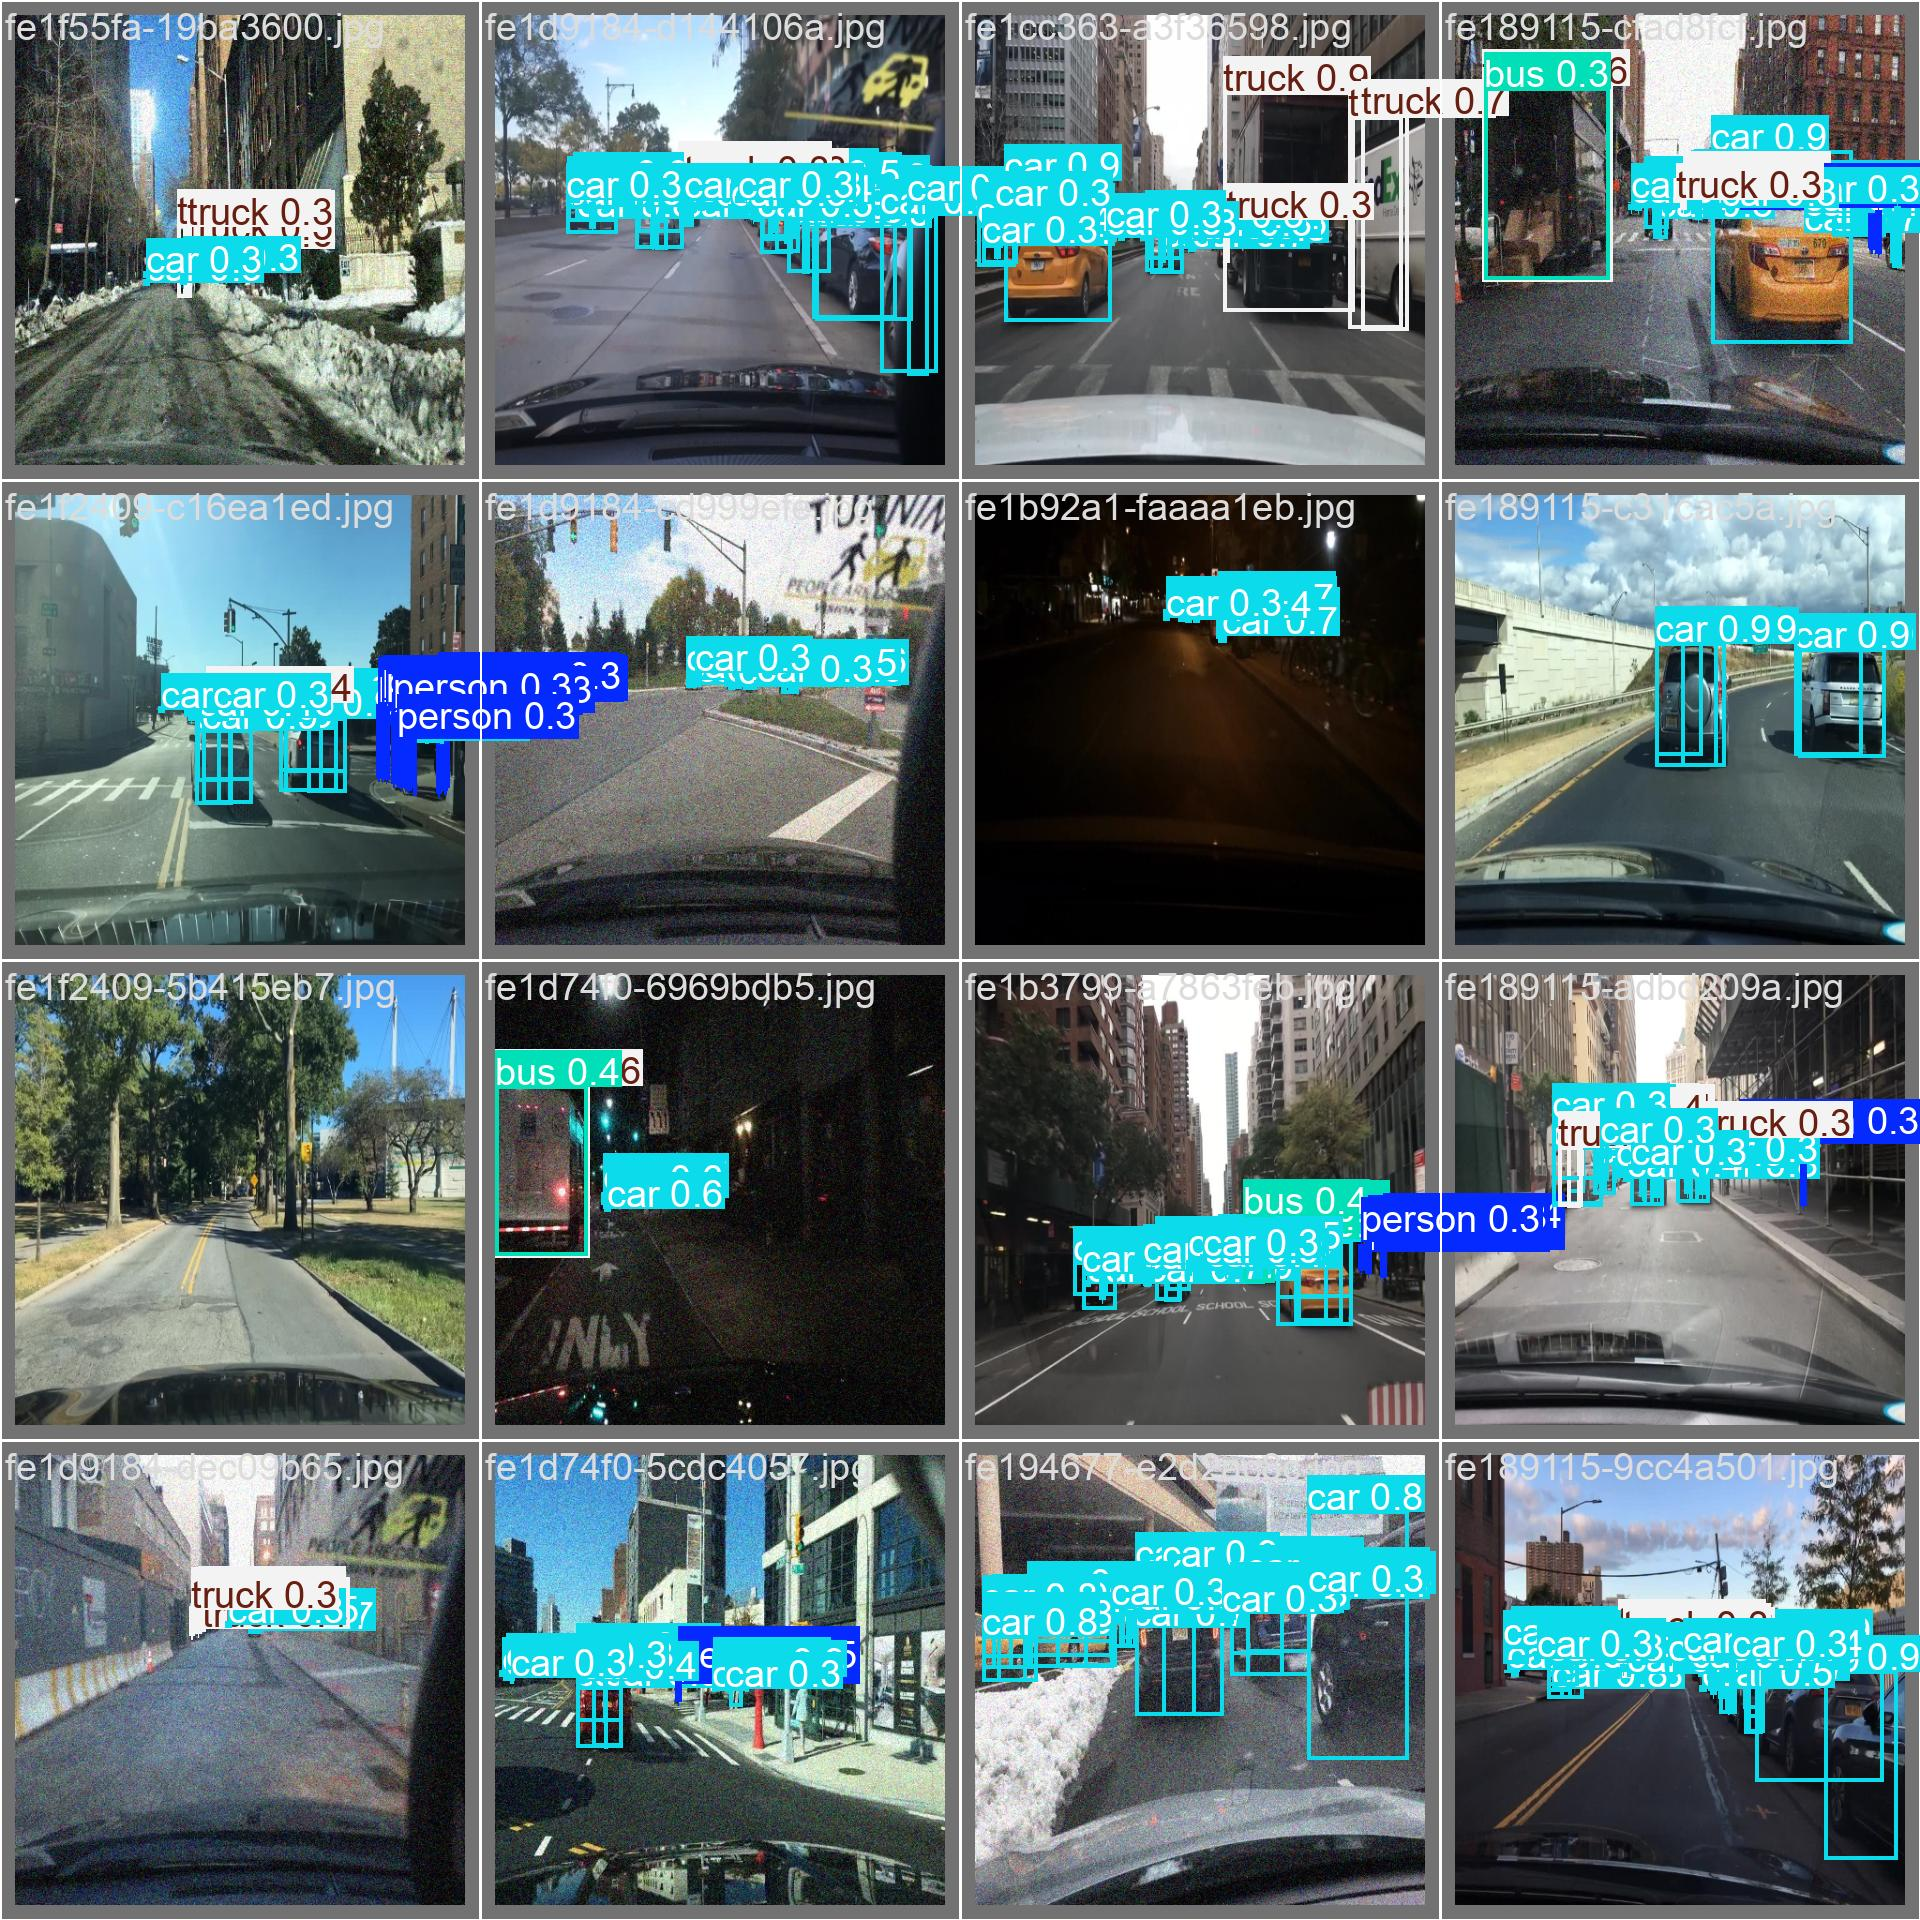
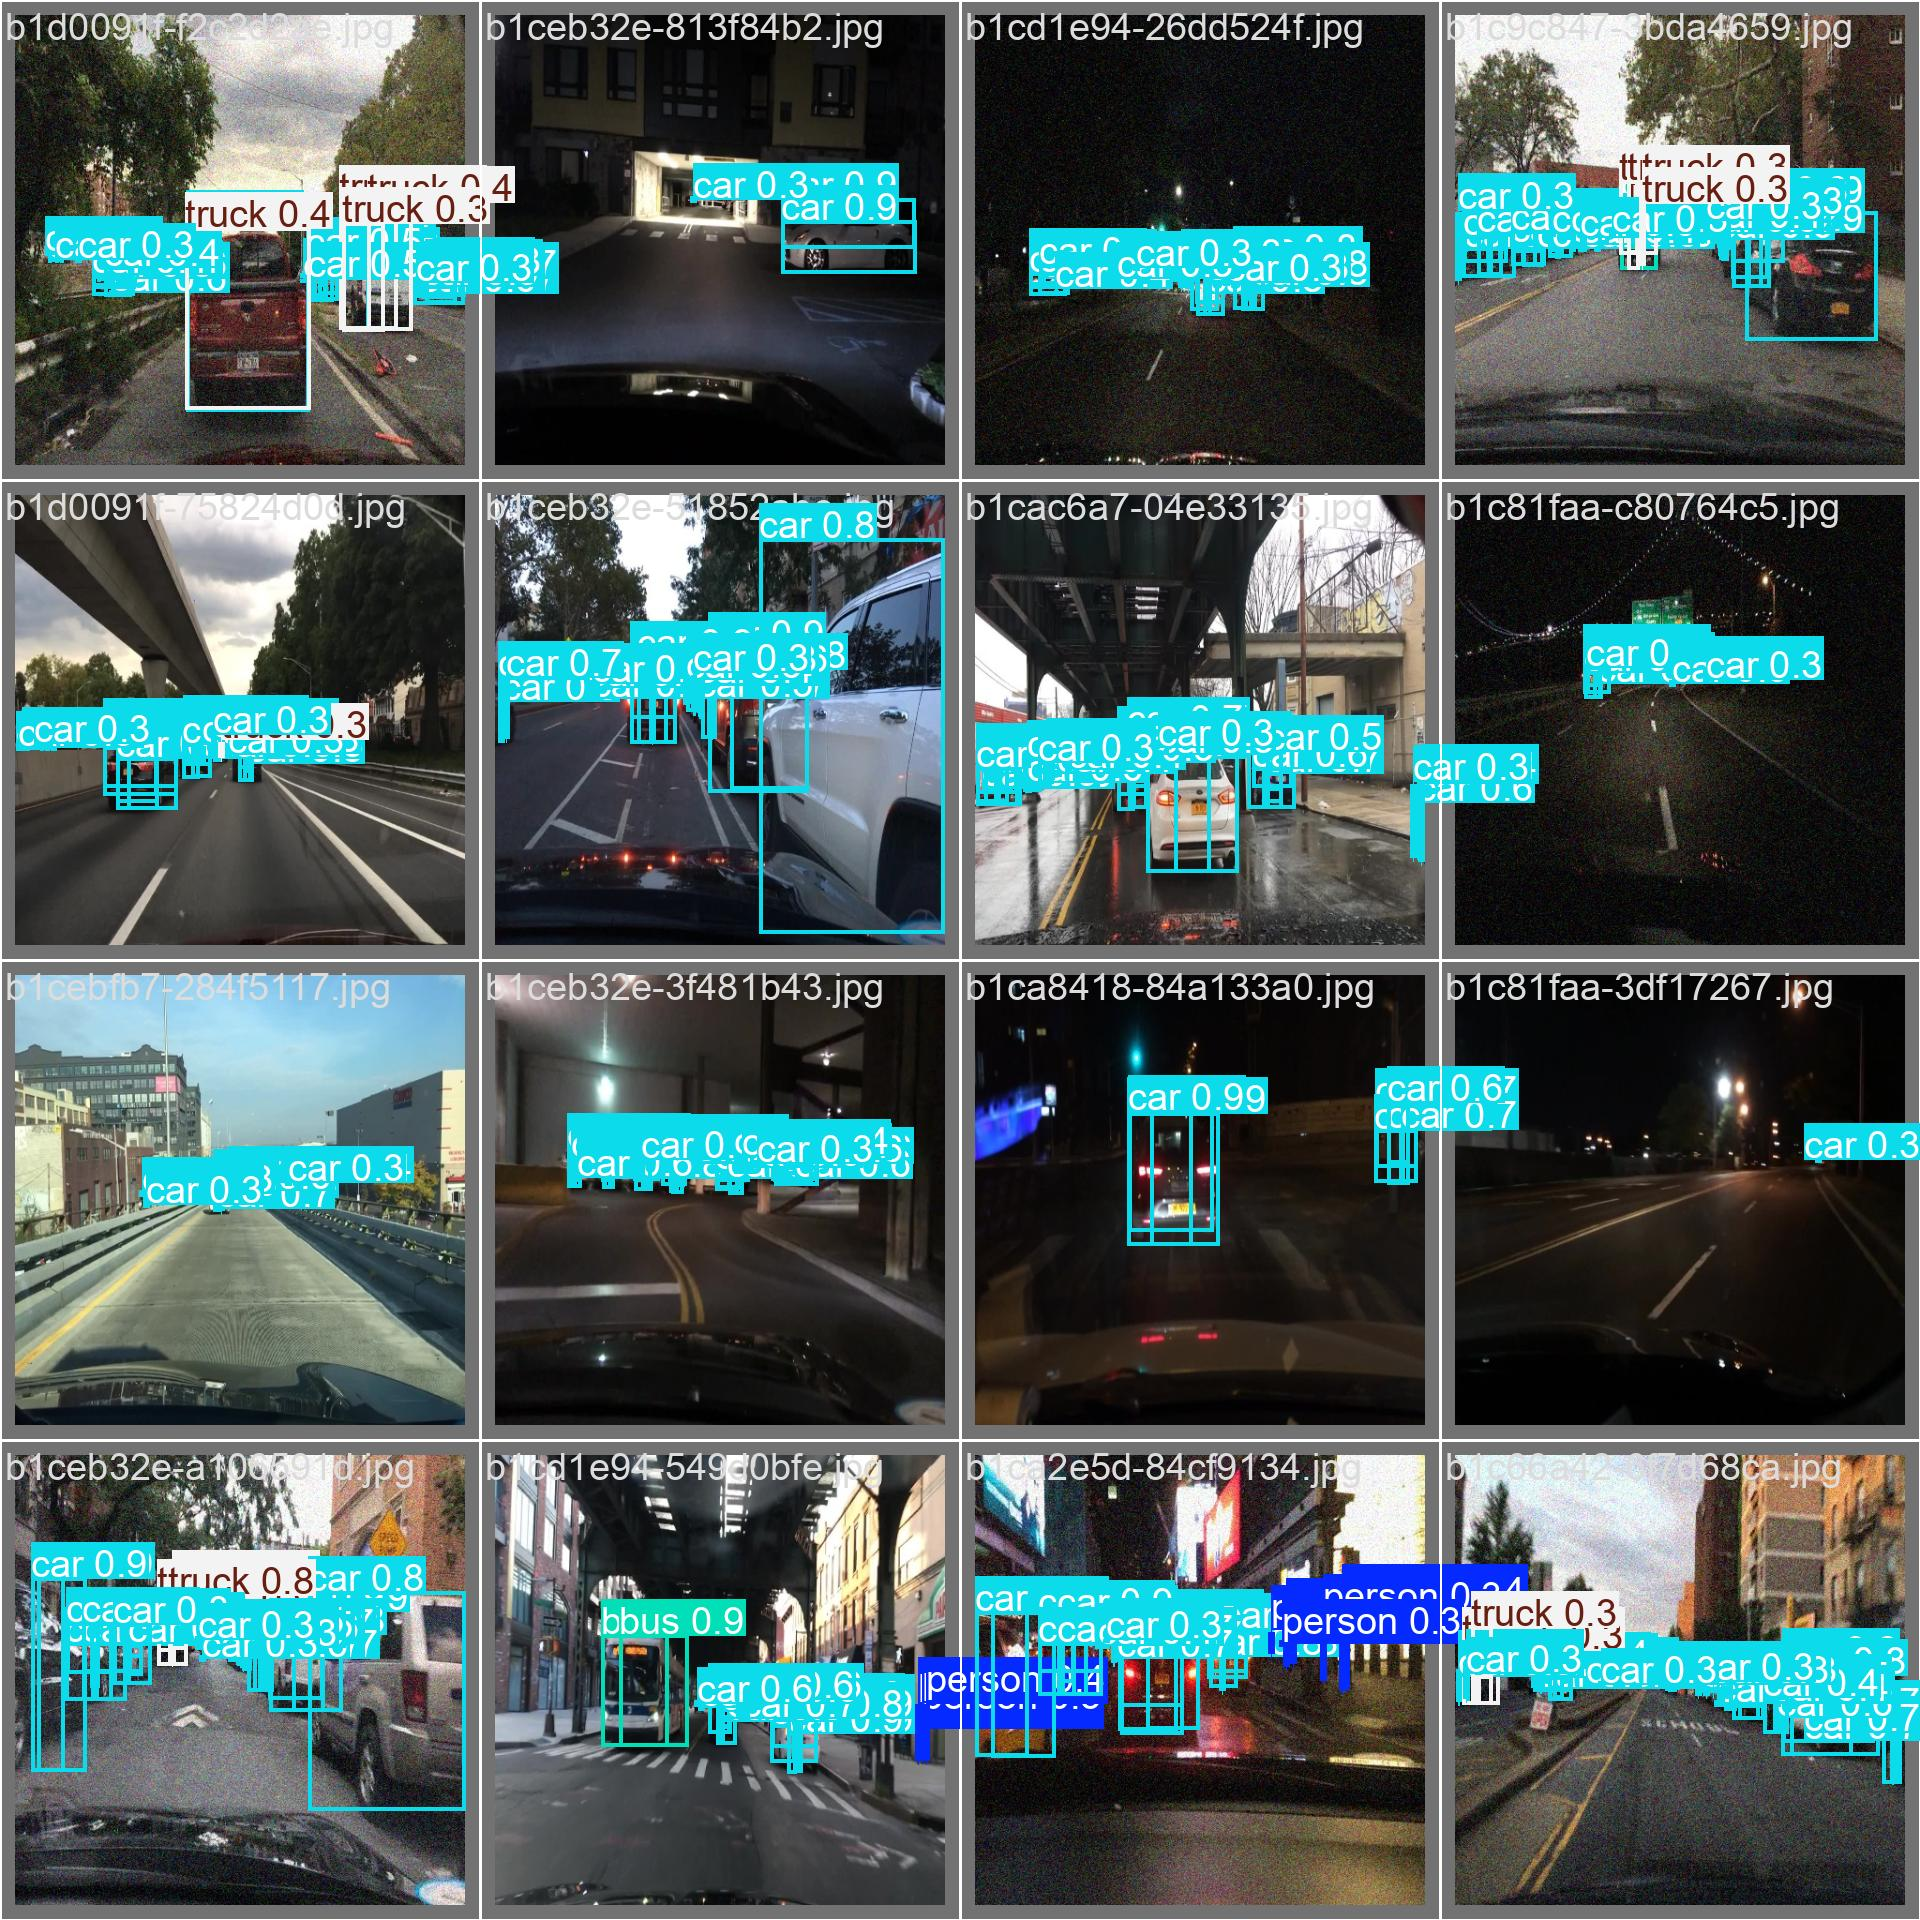